In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split,GridSearchCV,
                                     RandomizedSearchCV,cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor,
                              VotingRegressor,StackingRegressor)
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score
                             ,root_mean_squared_error)
import warnings
warnings.filterwarnings("ignore")

In [49]:
#!pip install -U ydata-profiling

In [50]:
df=pd.read_csv("/content/CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [51]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [52]:
df.shape

(205, 26)

In [53]:
#from ydata_profiling import ProfileReport
#profile=ProfileReport(df,title="Car Price prediction",explorative=True)
#profile.to_file("ydata.html")

In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [56]:
df=df.drop(columns=['car_ID'])
df.shape

(205, 25)

In [57]:
df['Brand']=df['CarName'].apply(lambda x : x.split()[0])
df['Brand'].nunique()

28

In [58]:
df=df.drop(columns='CarName')
df.shape

(205, 25)

In [59]:
x=df.drop(columns=['price'])
y=df['price']
x.shape,y.shape

((205, 24), (205,))

In [60]:
cat_col=x.select_dtypes(include=['object']).columns
num_col=x.select_dtypes(include=['int64','float64']).columns
cat_col.shape,num_col.shape

((10,), (14,))

In [61]:
cat_col

Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'Brand'],
      dtype='object')

In [63]:
num_col

Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')

In [71]:
df[cat_col].nunique()

,0
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
enginetype,7
cylindernumber,7
fuelsystem,8
Brand,28


In [70]:
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.329756,0.270844,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.255415,0.313597,2.07,3.11,3.29,3.41,4.17
compressionratio,205.0,10.142537,3.972040,7.00,8.60,9.00,9.40,23.00


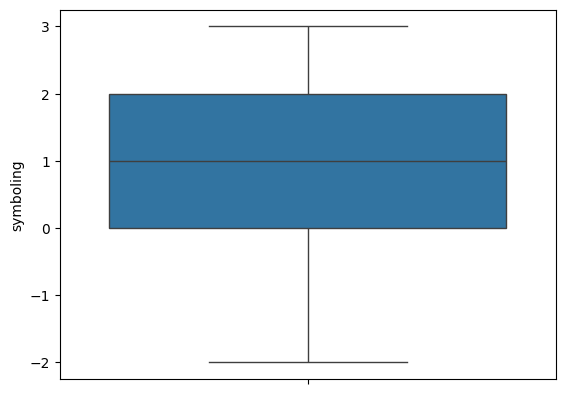

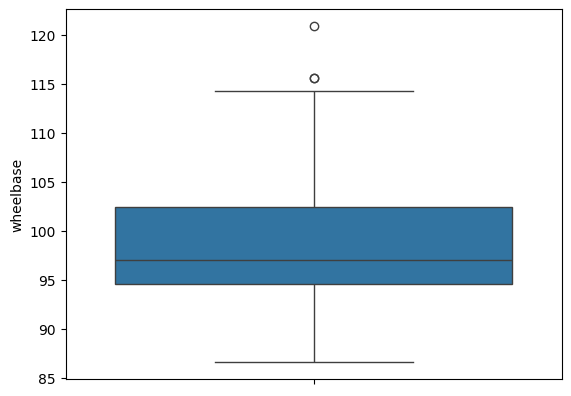

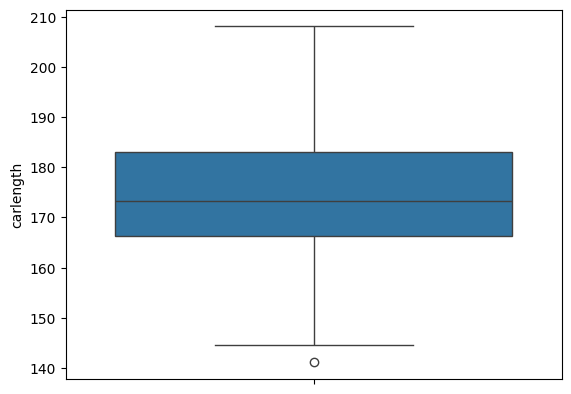

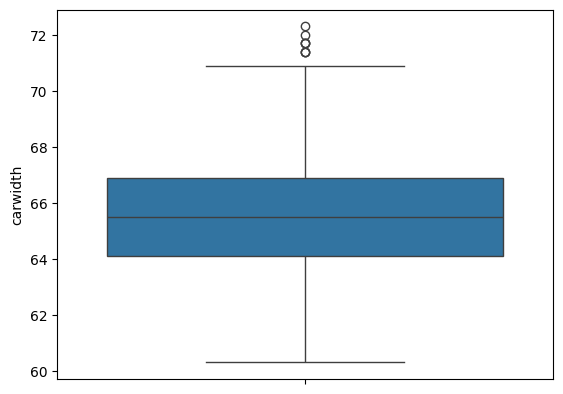

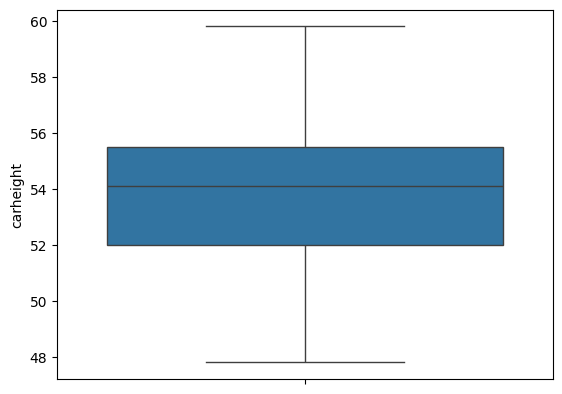

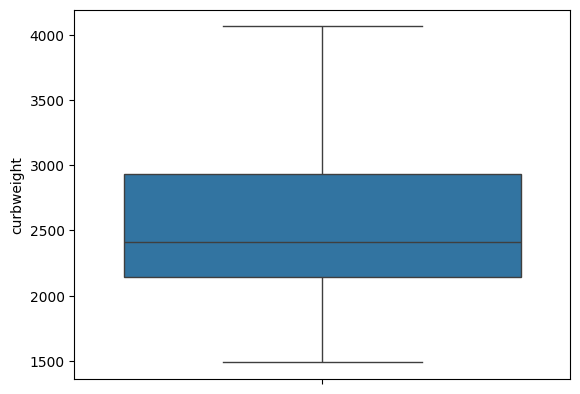

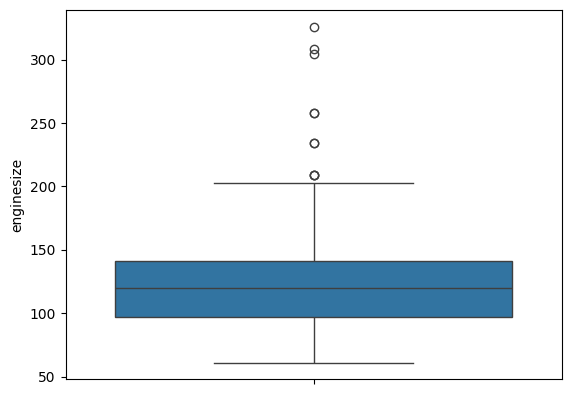

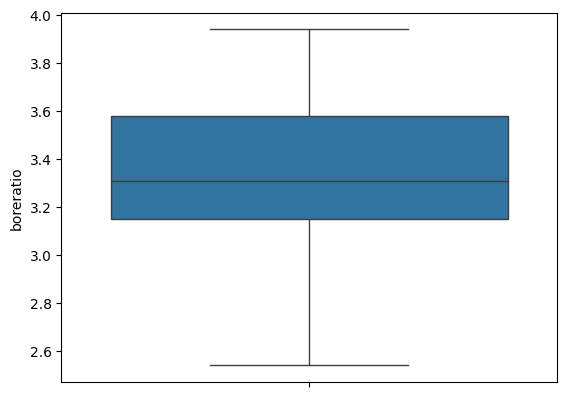

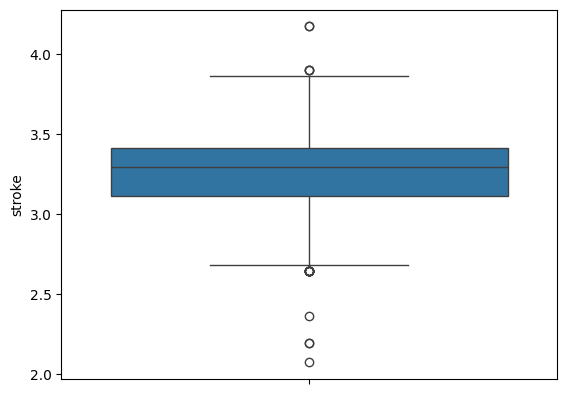

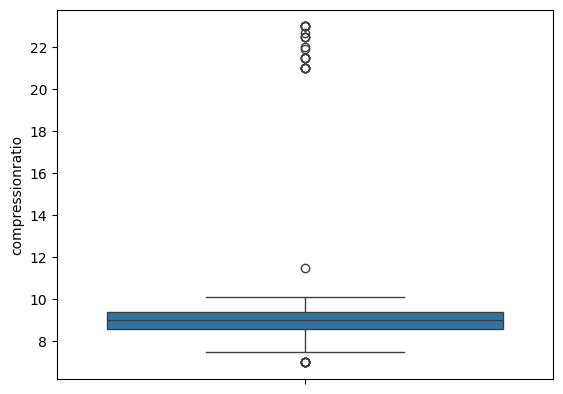

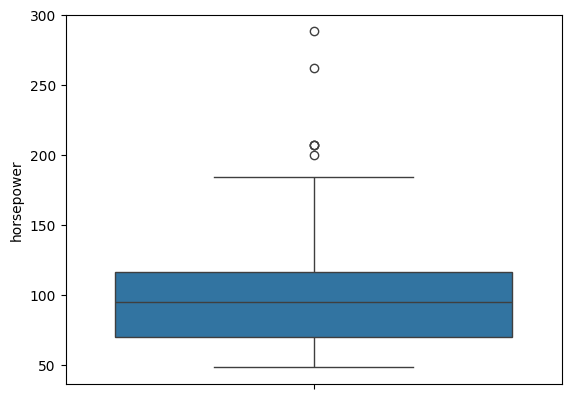

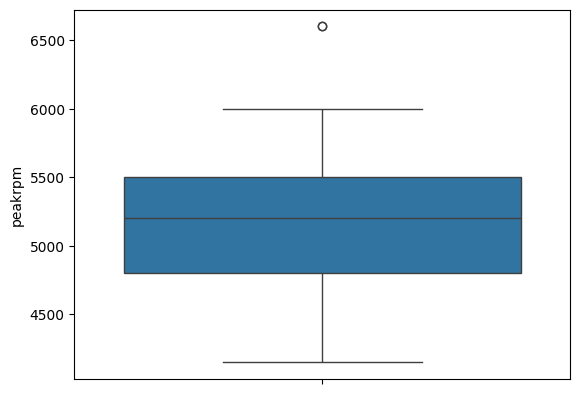

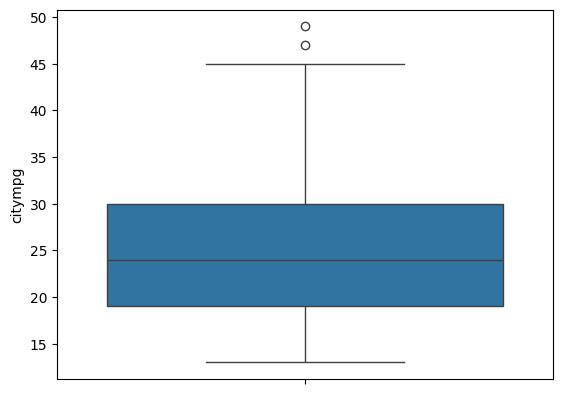

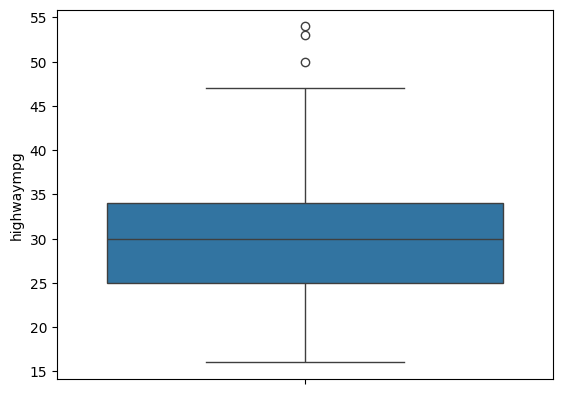

In [64]:
for col in num_col:
  sns.boxplot(df[col])
  plt.show()

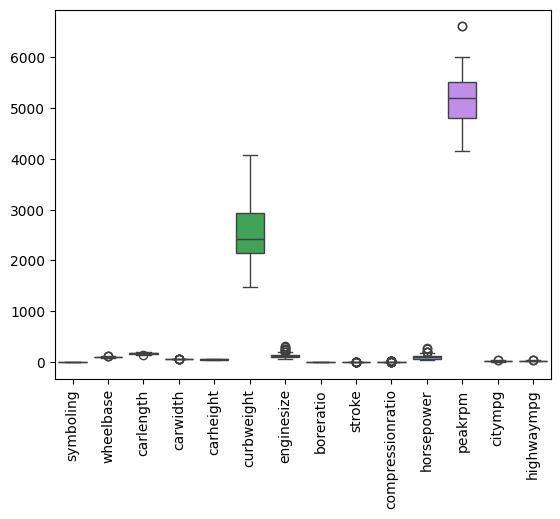

In [66]:
sns.boxplot(df[num_col])
plt.xticks(rotation=90)
plt.show()

In [101]:
cat_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encode",OneHotEncoder(handle_unknown="ignore"))
])
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
    ("scale",RobustScaler())
])
preprocesing=ColumnTransformer([
    ("cat",cat_pipeline,cat_col),
    ("num",num_pipeline,num_col)
])

In [74]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [87]:
lr_model=LinearRegression()

In [76]:
rf_model_pipeline=Pipeline([
    ("preprocesing",preprocesing),
    ("model",RandomForestRegressor(random_state=42,n_jobs=-1))
])
grid_param={
    "model__n_estimators":[50,100,150,200,300],
    "model__max_depth":[2,3,4,5,6,7,8],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
}
grid_search_rf=GridSearchCV(
    estimator=rf_model_pipeline,
    param_grid=grid_param,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    cv=5,
    verbose=2
)
grid_search_rf.fit(x_train,y_train)

Fitting 5 folds for each of 315 candidates, totalling 1575 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesing',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encode',
                                                                                          OneHotEncoder())]),
                                                                         Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'Brand'],
      dtype='object')),
                                                                        (...
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [2, 3, 4, 5, 6, 7, 8],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 150, 200, 300]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [80]:
print(-grid_search_rf.best_score_)
print(grid_search_rf.best_params_)

nan
{'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}


In [104]:
#rf_model=grid_search_rf.best_estimator_
rf_model=RandomForestRegressor(n_estimators=50,max_depth=2,min_samples_leaf=1,min_samples_split=2)

In [78]:
xbg_model_pipeline=Pipeline([
    ("preprocesing",preprocesing),
    ("model",GradientBoostingRegressor(random_state=42))
])
grid_param={
    "model__learning_rate":[0.01,0.1,0.2,0.5,1],
    "model__n_estimators":[100,200,300],
    "model__subsample":[0.1,0.5,1],
    "model__max_depth":[2,3,4,5,6,7,8],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
}
grid_search_xgb=GridSearchCV(
    estimator=xbg_model_pipeline,
    param_grid=grid_param,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    cv=5,
    verbose=2
)
grid_search_xgb.fit(x_train,y_train)

Fitting 5 folds for each of 2835 candidates, totalling 14175 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesing',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encode',
                                                                                          OneHotEncoder())]),
                                                                         Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'Brand'],
      dtype='object')),
                                                                        (...
      dtype='object'))])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.1, 0.2, 0.5, 1],
                         'model__max_depth': [2, 3, 4, 5, 6, 7, 8],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.1, 0.5, 1]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [83]:
print(-grid_search_xgb.best_score_)
print(grid_search_xgb.best_params_)

nan
{'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'model__subsample': 0.1}


In [106]:
#xgb_model=grid_search_xgb.best_estimator_
xgb_model=GradientBoostingRegressor(learning_rate=0.01,n_estimators=100,max_depth=2,min_samples_leaf=1,
                                    min_samples_split=2)

In [107]:
voting_model=VotingRegressor([
    ("lr",lr_model),
    ("rf",rf_model),
    ("xgb",xgb_model)
])

In [111]:
stacking_model=StackingRegressor([
    ("rf",rf_model),
    ("xgb",xgb_model)
],final_estimator=Ridge())

In [112]:
models={
    "LinearRegression":lr_model,
    "RandomForestRegressor":rf_model,
    "GradientBoostingRegressor":xgb_model,
    "VotingRegressor":voting_model,
    "StackingRegressor":stacking_model
}

In [119]:
result=[]
for name,esti  in models.items():
  pipe=Pipeline([
      ("preprocesing",preprocesing),
      ("model",esti )
  ])
  pipe.fit(x_train,y_train)
  pred=pipe.predict(x_test)
  r2=r2_score(y_test,pred)
  mse=mean_squared_error(y_test,pred)
  rmse=np.sqrt(mean_squared_error(y_test,pred))
  mae=mean_absolute_error(y_test,pred)

  result.append({
      "model":name ,
      "R2":r2,
      "MSE":mse,
      "RMSE":rmse,
      "MAE":mae
  })

result_df=pd.DataFrame(result).sort_values("R2",ascending=False)

In [120]:
result_df

,model,R2,MSE,RMSE,MAE
3,VotingRegressor,0.914152,5.808449e+06,2410.072420,1571.358901
1,RandomForestRegressor,0.903514,6.528185e+06,2555.031229,1936.106043
0,LinearRegression,0.889379,7.484566e+06,2735.793419,1774.926532
4,StackingRegressor,0.888527,7.542212e+06,2746.308742,2059.270683
2,GradientBoostingRegressor,0.815525,1.248147e+07,3532.912481,2741.393380


In [123]:
voting_pipe = Pipeline([
    ("preprocesing", preprocesing),
    ("model", voting_model)
])

score = cross_val_score(
    voting_pipe,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(score)
print("Mean R2:", score.mean())
print("Std:", score.std())

[0.87423142 0.92813333 0.8275218  0.89801912 0.84667793]
Mean R2: 0.8749167203959779
Std: 0.03580476149160838


In [126]:
best_model=result_df.iloc[0]['model']
best_model_obj=models[best_model]
final_pipeline=Pipeline([
    ("preprocesing",preprocesing),
    ("model",best_model_obj)
])

final_pipeline.fit(x_train,y_train)
y_pred=final_pipeline.predict(x_test)
print("r2_score:",r2_score(y_test,y_pred))

r2_score: 0.9117587437661405


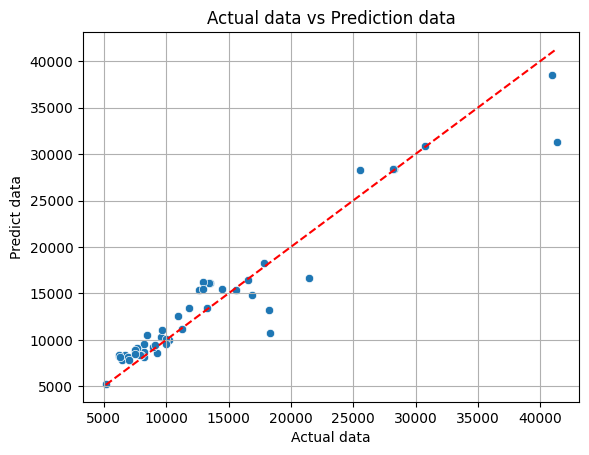

In [128]:
sns.scatterplot(x=y_test,y=y_pred,alpha=1)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color="red",linestyle='--')
plt.xlabel("Actual data")
plt.ylabel("Predict data")
plt.title("Actual data vs Prediction data")
plt.grid()
plt.show()

In [129]:
filename="model.pkl"
with open(filename,'wb') as file:
  pickle.dump(final_pipeline,file)